# Jupyter Notebook: EDA for Predictive Analytics Model  
**Development of a predictive analytics model for predicting sought-after professions based on data from vacancies**

**Authors:** Ashim Myrzakassymov, Baknur Berturganov, Nurdaulet Tastan  
**Group:** BDA-2304  
**Date:** April 2026  

**Purpose of this notebook:**  
Perform a complete Exploratory Data Analysis (EDA) on the `results.csv` file (1754 vacancies from hh.kz, March 2026). This notebook corresponds to **Section 6.4 Exploratory Data Analysis & Trend Identification** of the thesis.

---

## Cell 1 (Markdown)
```markdown
## 1. Import Libraries and Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

## 2. Load the Data

In [6]:
df = pd.read_csv('results.csv', encoding='utf-8-sig')

print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head(3)

Data loaded successfully!
Dataset shape: 1754 rows × 13 columns

Columns:
['Unnamed: 0', 'title', 'salary', 'city', 'job', 'publish_date', 'requirements', 'responsibilities', 'schedule', 'experience', 'employment', 'url', 'Job']


,Unnamed: 0,title,salary,city,job,publish_date,requirements,responsibilities,schedule,experience,employment,url,Job
0,0,Big Data аналитик (Junior),NaN,Алматы,"Beeline, ТМ",23-03-2026,"Отличные знания высшей математики, теории вероятности и математической статистики. Желание решат...",Проведение аналитических работ в своем направлении. Построение прогнозов и прогнозных моделей. В...,NaN,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/83688314,Data Analyst
1,1,Data аналитик,NaN,Алматы,"Центр развития города Алматы, АО",21-03-2026,Обязательное высшее техническое образование. Опыт работы в области <highlighttext>аналитики</hig...,Автоматизация и разработка алгоритмов для сбора и обработки (очистки и верификации) данных. Форм...,NaN,От 3 до 6 лет,Полная занятость,https://hh.ru/vacancy/82757292,Data Analyst
2,2,Data Analyst,NaN,Алматы,Казахстанско - Британский технический университет,22-03-2026,"Высшее образование в области компьютерных наук, математики, физики, эконометрики или смежных обл...","Проектирование и разработка автоматизированных решений для обработки данных (прием, обработка, <...",NaN,От 3 до 6 лет,Полная занятость,https://hh.ru/vacancy/83728215,Data Analyst


## 3. General Information about the Dataset

In [7]:
print("=== Dataset Information ===")
df.info()

print("\n=== Missing Values ===")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1754 non-null   int64  
 1   title             1754 non-null   object 
 2   salary            768 non-null    object 
 3   city              1754 non-null   object 
 4   job               1754 non-null   object 
 5   publish_date      1754 non-null   object 
 6   requirements      1715 non-null   object 
 7   responsibilities  1687 non-null   object 
 8   schedule          0 non-null      float64
 9   experience        1754 non-null   object 
 10  employment        1754 non-null   object 
 11  url               1754 non-null   object 
 12  Job               1754 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 178.3+ KB

=== Missing Values ===
schedule            1754
salary               986
responsibilities     

## 4. Data Cleaning and Transformation

In [9]:
## 4. Data Cleaning and Transformation

# 4.1 Convert publish_date to datetime
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d-%m-%Y', errors='coerce')

# 4.2 Improved salary parsing function
def parse_salary(salary_str):
    if pd.isna(salary_str) or str(salary_str).strip() == '':
        return np.nan

    # Convert to string and clean
    s = str(salary_str).strip()

    # Extract all numbers
    numbers = re.findall(r'\d+', s)
    if not numbers:
        return np.nan

    # Convert to integers
    nums = [int(n) for n in numbers]

    # Return average if range is given (e.g. 400000 - 650000)
    return np.mean(nums)

# Apply the function
df['salary_numeric'] = df['salary'].apply(parse_salary)

# 4.3 Clean experience column
experience_map = {
    'Нет опыта': 'No experience',
    'От 1 года до 3 лет': '1-3 years',
    'От 3 до 6 лет': '3-6 years',
    'Более 6 лет': '6+ years'
}
df['experience_clean'] = df['experience'].map(experience_map).fillna('Unknown')

# Show clean results
print("✅ Data cleaning completed!\n")
print(f"Number of vacancies with salary specified: {df['salary_numeric'].notna().sum()} out of {len(df)}")

# Nice formatted table
from IPython.display import display
display(df[['salary', 'salary_numeric']].head(10))

# Quick salary statistics
print("\n=== Salary Statistics (KZT) ===")
print(df['salary_numeric'].describe())

✅ Data cleaning completed!

Number of vacancies with salary specified: 768 out of 1754


,salary,salary_numeric
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,700000 KZT,700000.0
9,NaN,NaN



=== Salary Statistics (KZT) ===
count    7.680000e+02
mean     3.604831e+05
std      2.675872e+05
min      2.500000e+02
25%      2.000000e+05
50%      3.000000e+05
75%      4.750000e+05
max      2.000000e+06
Name: salary_numeric, dtype: float64


## 5. Analysis of Professions (Job Category)

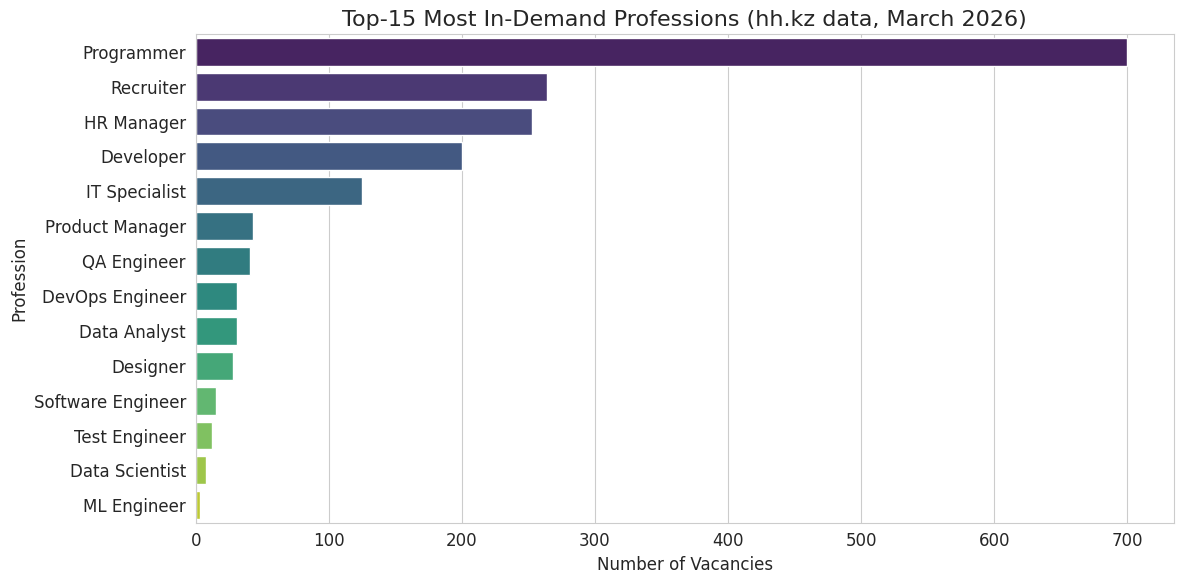

Job
Programmer           700
Recruiter            264
HR Manager           253
Developer            200
IT Specialist        125
Product Manager       43
QA Engineer           41
DevOps Engineer       31
Data Analyst          31
Designer              28
Software Engineer     15
Test Engineer         12
Data Scientist         8
ML Engineer            3
Name: count, dtype: int64


In [10]:
# Top-15 professions
top_jobs = df['Job'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title('Top-15 Most In-Demand Professions (hh.kz data, March 2026)', fontsize=16)
plt.xlabel('Number of Vacancies')
plt.ylabel('Profession')
plt.tight_layout()
plt.show()

print(top_jobs)

## 6. Geographic Analysis

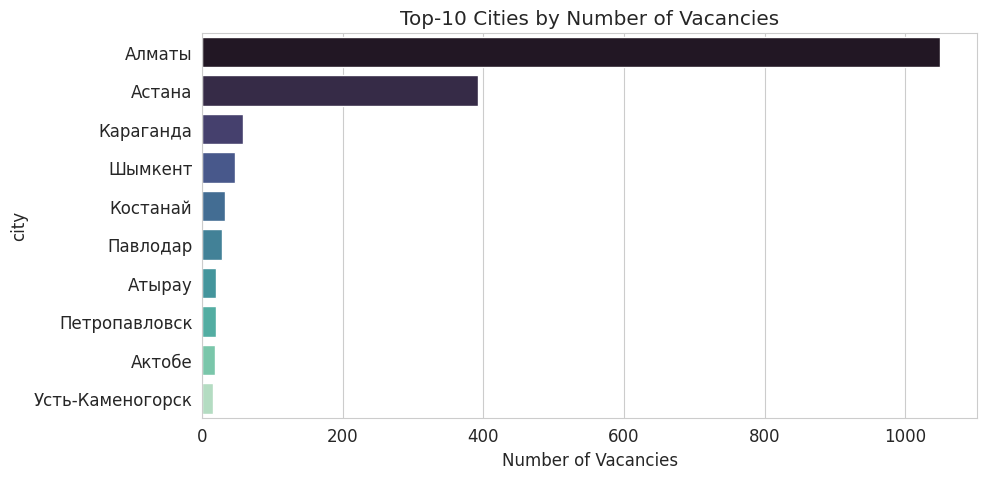

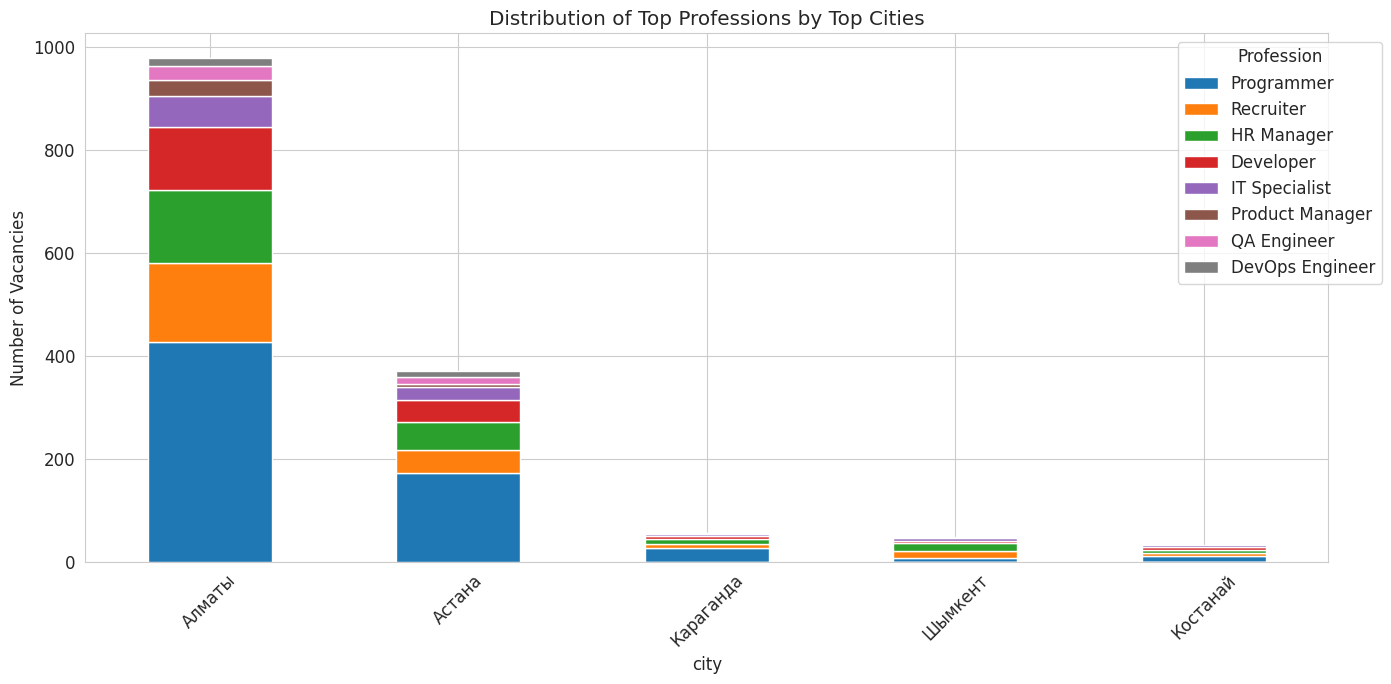

In [11]:
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='mako')
plt.title('Top-10 Cities by Number of Vacancies')
plt.xlabel('Number of Vacancies')
plt.show()

# Distribution of top professions by top cities
city_job = pd.crosstab(df['city'], df['Job'])
top_cities_jobs = city_job.loc[top_cities.index[:5], top_jobs.index[:8]]
top_cities_jobs.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Distribution of Top Professions by Top Cities')
plt.ylabel('Number of Vacancies')
plt.xticks(rotation=45)
plt.legend(title='Profession', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 7. Analysis of Experience

TypeError: 'Axes' object is not subscriptable

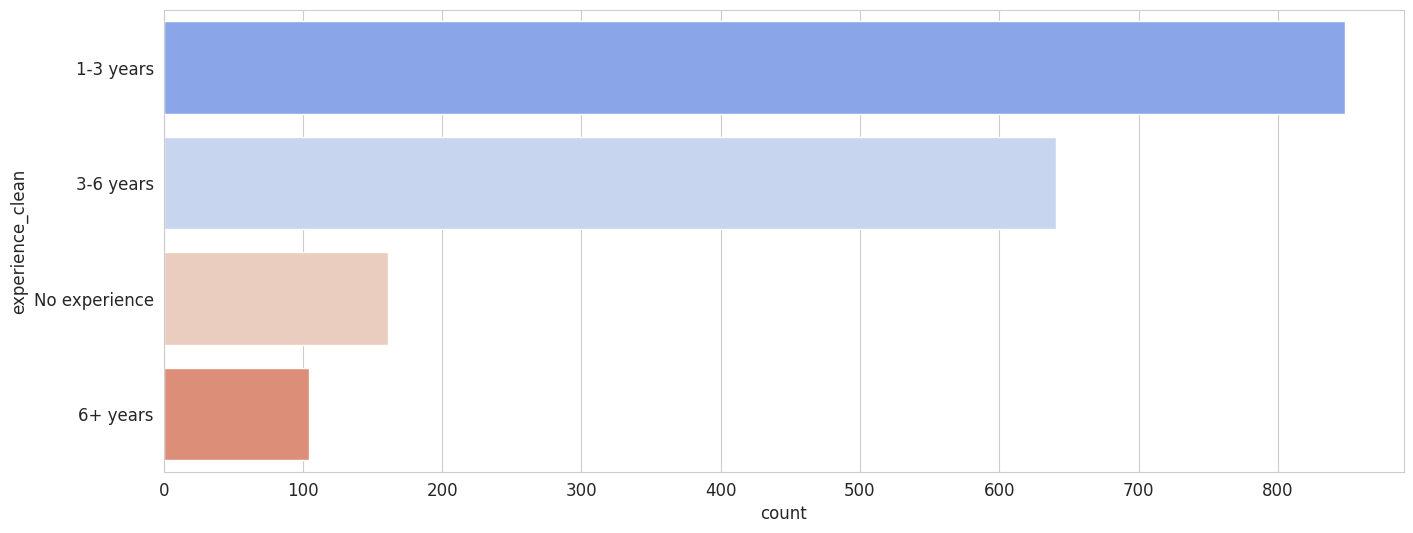

In [15]:
fig, axes = plt.subplots(1, figsize=(16, 6))

# Experience distribution
sns.countplot(data=df, y='experience_clean',
              order=df['experience_clean'].value_counts().index,
              ax=axes, palette='coolwarm')
axes[0].set_title('Distribution by Work Experience')


plt.tight_layout()
plt.show()

## 8. Salary Analysis

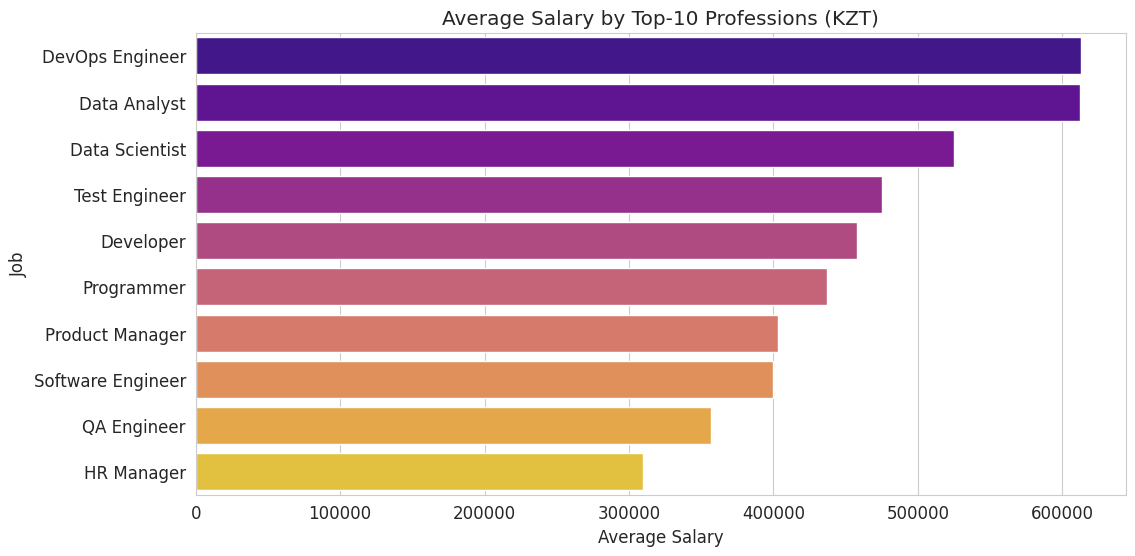

Job
DevOps Engineer      613250.000000
Data Analyst         612500.000000
Data Scientist       525000.000000
Test Engineer        475000.000000
Developer            458152.083333
Programmer           436995.582707
Product Manager      402937.500000
Software Engineer    400000.000000
QA Engineer          356750.000000
HR Manager           309917.884106
Name: salary_numeric, dtype: float64


In [16]:
# Average salary by top professions
salary_by_job = df.groupby('Job')['salary_numeric'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=salary_by_job.values, y=salary_by_job.index, palette='plasma')
plt.title('Average Salary by Top-10 Professions (KZT)')
plt.xlabel('Average Salary')
plt.show()

print(salary_by_job)

## 9. Skill Extraction (Basic NLP)

=== Top Single-Word Technical Skills (Final) ===
               Skill  Count
0         разработка    620
1          персонала    407
2         разработки    345
3         приложений    226
4             данных    203
5         проведение    198
6             систем    143
7         javascript    140
8            ведение    131
9         разработке    129
10         доработка    121
11           подбора    121
12  программирования    120
13          создание    116
14          вакансий    115

=== Top Skill Phrases (Bigrams) ===
                         Skill  Count
0     программного обеспечения     80
1                     html css     72
2               веб приложений     60
3            подбора персонала     59
4           уверенное владение     48
5            подборе персонала     42
6                 платформе 1с     40
7               1с предприятие     39
8   кадрового делопроизводства     39
9         мобильных приложений     37
10              грамотная речь     37
11       п

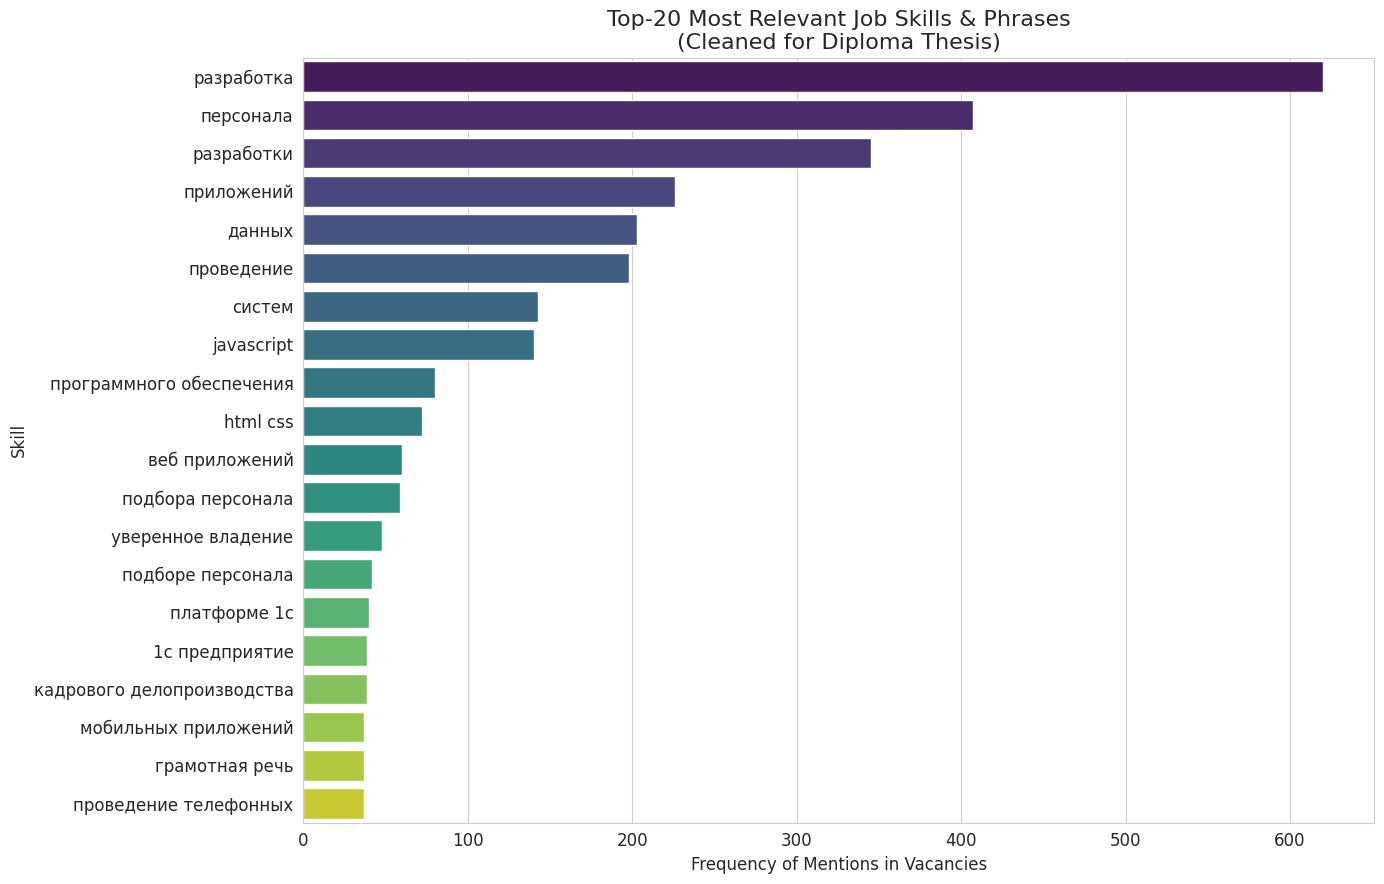

In [20]:
## 9. Skill Extraction (Final Version for Thesis)

# Combine text
df['full_text'] = df['requirements'].fillna('') + ' ' + df['responsibilities'].fillna('')

def clean_text(text):
    text = re.sub(r'<[^>]+>', '', str(text))
    text = re.sub(r'[^a-zA-Zа-яА-Я0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).lower().strip()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

# Final strong stopword + generic filter list
stopwords = {
    'и','в','на','с','по','для','от','до','не','что','как','это','за','из','у','к','о','но','или','при',
    'работы','работа','опыт','знание','умение','навыки','требования','обязанности','высшее','образование',
    'команда','проект','задач','задачи','работать','поиск','подбор','кандидатов','поддержка','знания',
    'сфере','новых','компании','понимание','участие','менее','года','лет','год','месяц','х','1','2','3','4','5','6',
    'experience','in','years','of','with','and','for','the'
}

words = []
bigrams = []

for text in df['clean_text']:
    tokens = text.split()
    for i, token in enumerate(tokens):
        if token not in stopwords and len(token) > 3:
            words.append(token)

        if i < len(tokens)-1:
            bigram = tokens[i] + ' ' + tokens[i+1]
            if tokens[i] not in stopwords and tokens[i+1] not in stopwords:
                bigrams.append(bigram)

word_freq = Counter(words)
bigram_freq = Counter(bigrams)

top_words = pd.DataFrame(word_freq.most_common(15), columns=['Skill', 'Count'])
top_bigrams = pd.DataFrame(bigram_freq.most_common(20), columns=['Skill', 'Count'])

print("=== Top Single-Word Technical Skills (Final) ===")
print(top_words)

print("\n=== Top Skill Phrases (Bigrams) ===")
print(top_bigrams.head(15))

# Visualization
combined = pd.concat([top_words.head(8), top_bigrams.head(12)])
combined = combined.sort_values('Count', ascending=False).drop_duplicates(subset=['Skill'])

plt.figure(figsize=(14, 9))
sns.barplot(data=combined, x='Count', y='Skill', palette='viridis')
plt.title('Top-20 Most Relevant Job Skills & Phrases\n(Cleaned for Diploma Thesis)', fontsize=16)
plt.xlabel('Frequency of Mentions in Vacancies')
plt.tight_layout()
plt.show()

## 10. Key Insights for the Predictive Model

In [22]:
print("=== KEY INSIGHTS FOR THE PREDICTIVE MODEL ===")
print(f"• Total vacancies: {len(df):,}")
print(f"• Most in-demand profession: {top_jobs.index[0]} ({top_jobs.iloc[0]} vacancies)")
print(f"• Most popular city: {top_cities.index[0]}")
print(f"• Average salary across dataset: {df['salary_numeric'].mean():,.0f} KZT")
print(f"• Most common experience level: {df['experience_clean'].mode()[0]}")

=== KEY INSIGHTS FOR THE PREDICTIVE MODEL ===
• Total vacancies: 1,754
• Most in-demand profession: Programmer (700 vacancies)
• Most popular city: Алматы
• Average salary across dataset: 360,483 KZT
• Most common experience level: 1-3 years
